In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from grt.spatial.manifold.domain import SphericalBall
from grt.spatial.manifold.metric import SphericalRMetric
from grt.spatial.manifold.grid import UniformCartesianGrid
from grt.spatial.influx.grid import UniformSphericalBeamGrid
from grt.spatial.geodesics import Geodesics
from grt.spatial.ray_transform import RayTransform
from grt.spatial.phantoms import shepp_logan
from grt.spatial.plotting import plot_phantom, plot_reconstruction, plot_sinogram
from grt.reconstruction import steepest_gradient_descent, conjugate_gradient_method

In [2]:
domain = SphericalBall(1.0)
metric = SphericalRMetric(2.0)

In [3]:
domain_grid = UniformCartesianGrid(domain, metric, shape=(64, 64, 64))

In [4]:
n_th, n_phi = 32, 64
n_alpha, n_gamma = 32, 64

influx_grid = UniformSphericalBeamGrid(n_th, n_phi, n_alpha, n_gamma, metric, domain, domain_grid)

In [5]:
geodesics = Geodesics(metric, domain, influx_grid, step_size=0.02, max_length=10.0)

In [6]:
ray_transform = RayTransform(geodesics, domain, domain_grid, influx_grid)

In [7]:
ray_transform.matrix.shape, ray_transform.matrix.count_nonzero()

((4194304, 137376), np.int64(250259568))

In [8]:
del geodesics

In [9]:
f_c = domain_grid.coefficients_from_function(shepp_logan)
y = ray_transform.matrix @ f_c
sinogram = (1 / np.sqrt(influx_grid.cell_areas)) * y

In [10]:
sgd = steepest_gradient_descent(ray_transform.matrix, y, np.zeros(shape=f_c.shape), 0.01)

iterating...
error threashold is satisfied.


In [11]:
cgm = conjugate_gradient_method(ray_transform.matrix, y, np.zeros(shape=f_c.shape), 0.01)

iterating...
error threashold is satisfied.


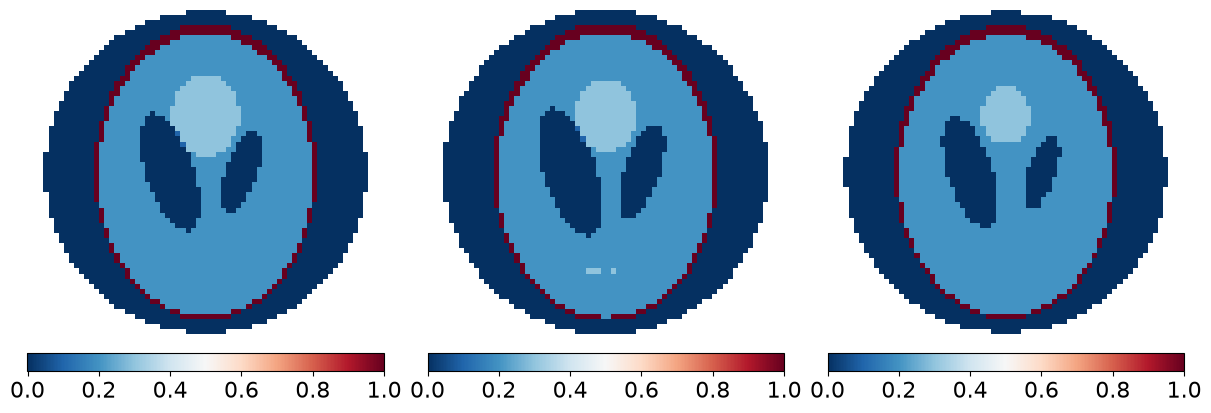

In [12]:
plot_phantom(truth=f_c, domain=domain, domain_grid=domain_grid)

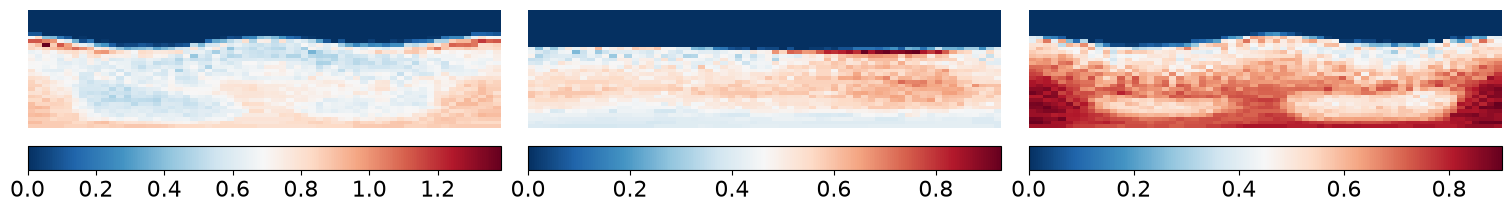

In [13]:
plot_sinogram(sinogram, domain=domain, influx_grid=influx_grid)

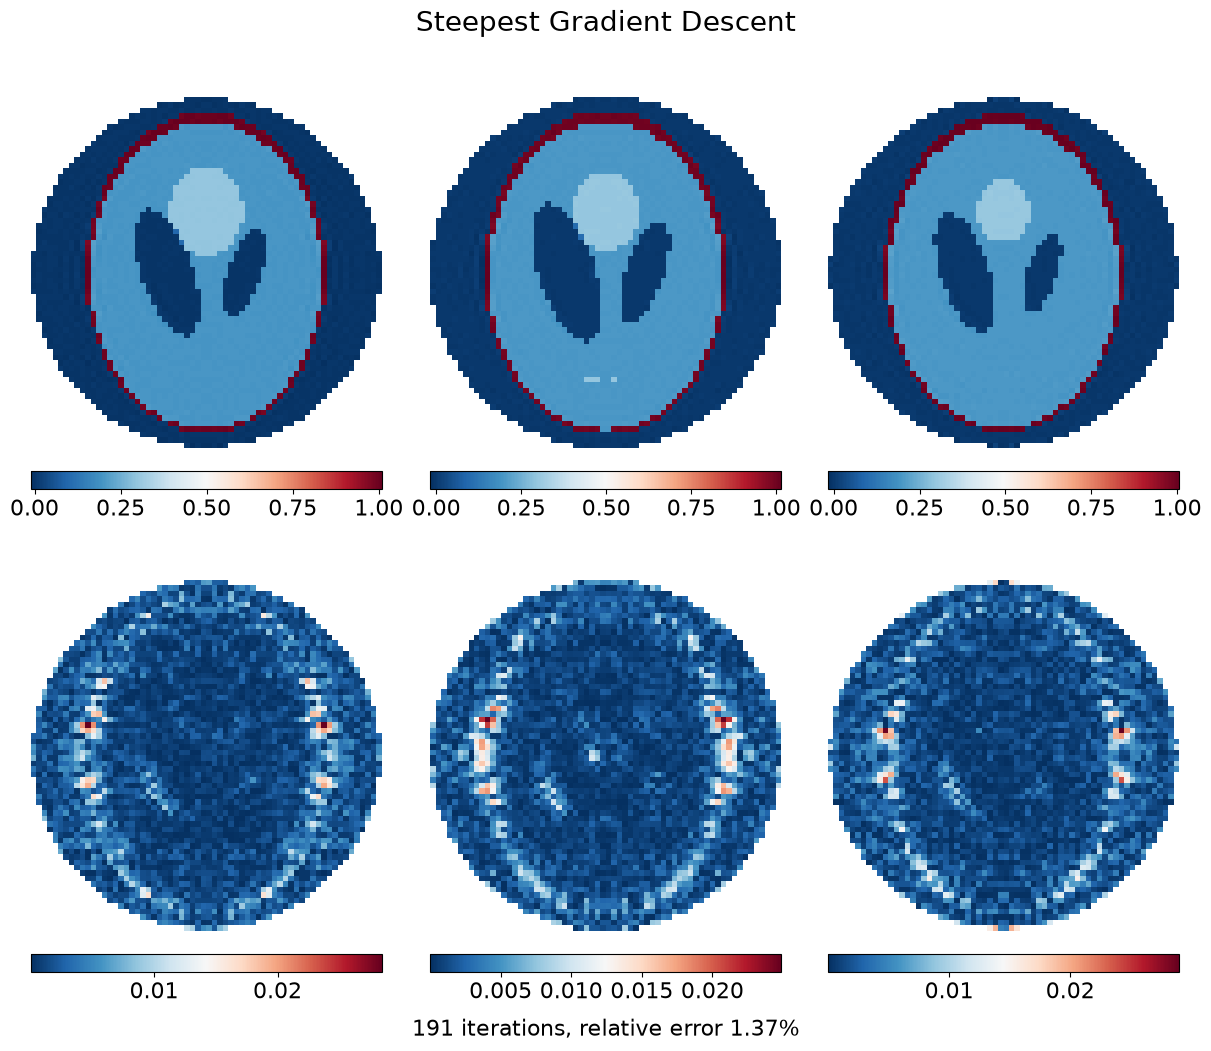

In [14]:
plot_reconstruction(truth=f_c, output=sgd, domain=domain, domain_grid=domain_grid)

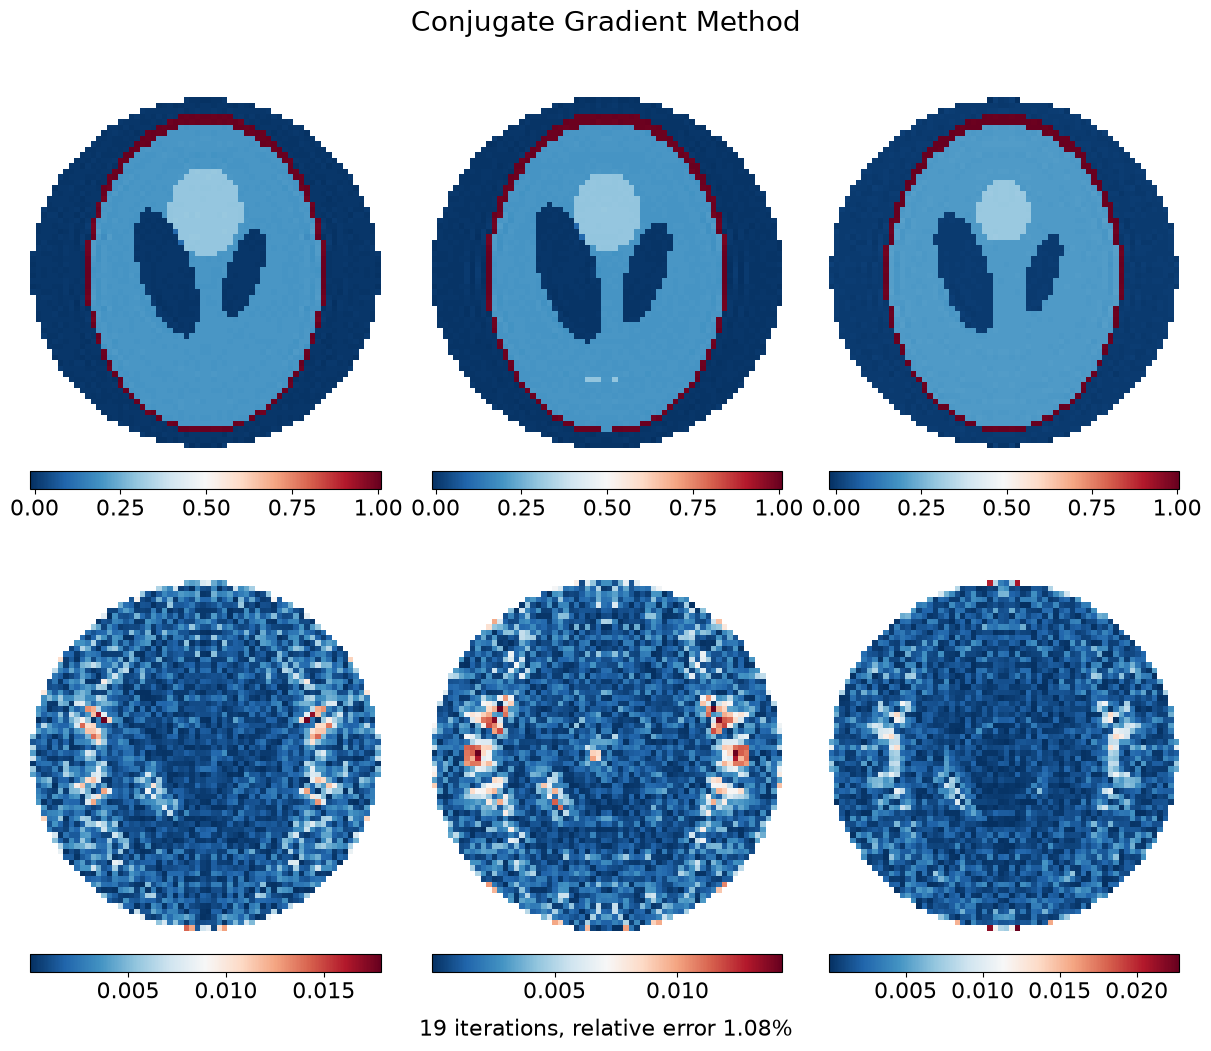

In [15]:
plot_reconstruction(truth=f_c, output=cgm, domain=domain, domain_grid=domain_grid)